# Phase 3: Baseline Fault Detection & Diagnosis Models

Trains and evaluates the two baseline tasks: **detection** (is something wrong?) and **diagnosis** (which of the 20 faults, given something's wrong?), using RandomForest and sklearn's native HistGradientBoostingClassifier.

Evaluation goes beyond plain accuracy -- detection delay and false alarm rate are what actually matter for a monitoring system, not just whether the classifier is accurate on a static test set.

**Note on faults 3, 9, 15:** these are documented in the literature as statistically very difficult or impossible to detect from this data -- if the model struggles specifically on these three, that's an expected property of the process, not a bug. See `data/external/fault_descriptions.csv`.

In [2]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from features import split_by_run, SENSOR_COLUMNS
from train import (
    train_detection_model, train_diagnosis_model,
    evaluate_detection_model, evaluate_diagnosis_model,
)
from evaluate import detection_delay

plt.rcParams['figure.figsize'] = (9, 5)

fault_descriptions = pd.read_csv('../data/external/fault_descriptions.csv')
HARD_FAULTS = [3, 9, 15]  # literature-documented as statistically undetectable

## 1. Load data

In [2]:
train_full = pd.read_parquet('../data/processed/tep_training.parquet')
n_run_instances = train_full.groupby(['faultNumber', 'simulationRun']).ngroups
print(f'{len(train_full):,} rows, {n_run_instances} distinct (fault, run) instances, '
      f'{train_full["faultNumber"].nunique()} fault scenarios')
# NOTE: simulationRun numbers (e.g. 1-500) REPEAT across every fault scenario --
# they are not globally unique run IDs, so .nunique() on simulationRun alone
# would undercount the actual number of distinct runs.
train_full.head()

5,250,000 rows, 10500 distinct (fault, run) instances, 21 fault scenarios


,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11,fault_active
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447,False
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194,False
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530,False
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089,False
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461,False


### 1a. Fault-active balance
Reminder: fault_active accounts for onset timing -- a 'faulty run' has normal (pre-onset) samples too, not just fault samples.

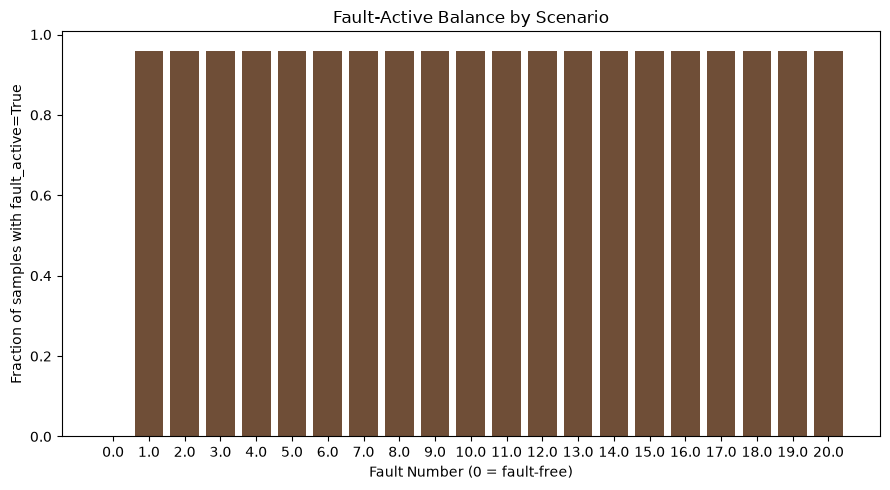

In [3]:
balance = train_full.groupby('faultNumber')['fault_active'].mean()
fig, ax = plt.subplots()
ax.bar(balance.index.astype(str), balance.values, color='#6f4e37')
ax.set_xlabel('Fault Number (0 = fault-free)')
ax.set_ylabel('Fraction of samples with fault_active=True')
ax.set_title('Fault-Active Balance by Scenario')
plt.tight_layout()
plt.show()

## 2. Train/validation split (by run, not by row)

In [4]:
train_df, val_df = split_by_run(train_full, val_frac=0.2, seed=42)
n_train_instances = train_df.groupby(['faultNumber', 'simulationRun']).ngroups
n_val_instances = val_df.groupby(['faultNumber', 'simulationRun']).ngroups
print(f'Train: {len(train_df):,} rows across {n_train_instances} (fault, run) instances')
print(f'Val:   {len(val_df):,} rows across {n_val_instances} (fault, run) instances')

overlap = set(zip(train_df.faultNumber, train_df.simulationRun)) & \
          set(zip(val_df.faultNumber, val_df.simulationRun))
print(f'(faultNumber, simulationRun) pairs in both splits: {len(overlap)} (should be 0)')

Train: 4,200,000 rows across 8400 (fault, run) instances
Val:   1,050,000 rows across 2100 (fault, run) instances
(faultNumber, simulationRun) pairs in both splits: 0 (should be 0)


## 3. Fault detection (binary)
Comparing both model types side by side.

In [5]:
detection_results = {}
for model_type in ['random_forest', 'hist_gradient_boosting']:
    model = train_detection_model(train_df, model_type=model_type, seed=42)
    metrics = evaluate_detection_model(model, val_df)
    detection_results[model_type] = metrics

detection_comparison = pd.DataFrame(detection_results).T
detection_comparison

,accuracy,precision,recall,f1,n_faulty_runs,detection_rate,mean_delay_samples,median_delay_samples,false_alarm_rate
random_forest,0.944155,0.951881,0.988910,0.970043,2000.0,1.0,0.000,0.0,0.533233
hist_gradient_boosting,0.939056,0.944393,0.991738,0.967486,2000.0,1.0,0.562,0.0,0.622878


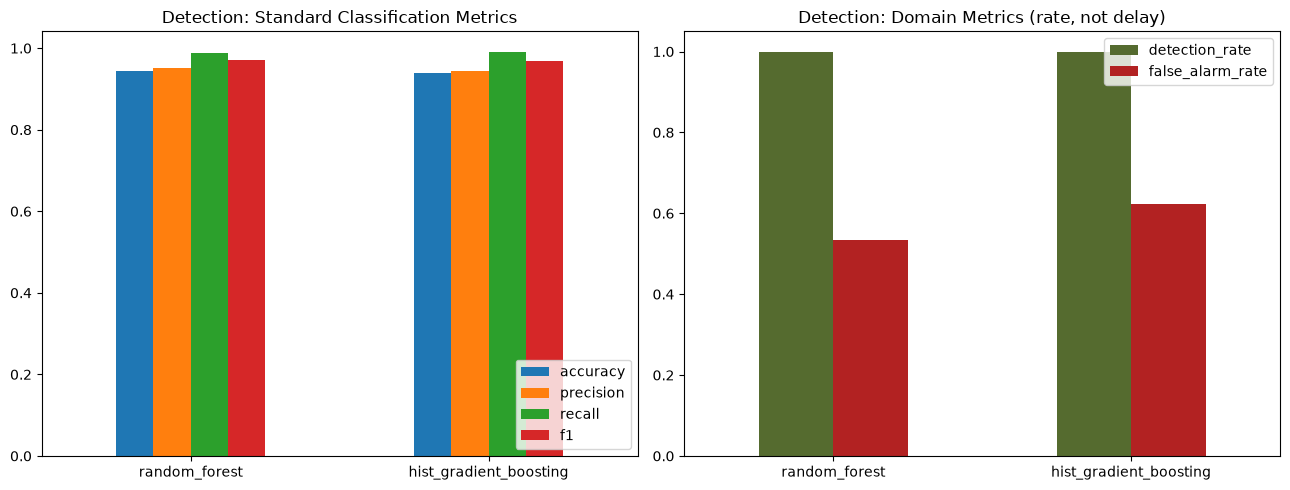

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
detection_comparison[metrics_to_plot].plot(kind='bar', ax=axes[0])
axes[0].set_title('Detection: Standard Classification Metrics')
axes[0].set_xticklabels(detection_comparison.index, rotation=0)
axes[0].legend(loc='lower right')

domain_metrics = ['detection_rate', 'false_alarm_rate']
detection_comparison[domain_metrics].plot(kind='bar', ax=axes[1], color=['#556b2f', '#b22222'])
axes[1].set_title('Detection: Domain Metrics (rate, not delay)')
axes[1].set_xticklabels(detection_comparison.index, rotation=0)
plt.tight_layout()
plt.show()

### 3a. Detection delay distribution
How many samples after true onset until the model catches it, per fault scenario?

In [7]:
best_model_type = detection_comparison['f1'].idxmax()
print(f'Using {best_model_type} (highest F1) for the delay breakdown below')

model = train_detection_model(train_df, model_type=best_model_type, seed=42)
feature_columns = [c for c in SENSOR_COLUMNS if c in val_df.columns]
val_df = val_df.copy()
val_df['predicted'] = model.predict(val_df[feature_columns])

delays = detection_delay(val_df)
delays['is_hard_fault'] = delays['faultNumber'].isin(HARD_FAULTS)
delays

Using random_forest (highest F1) for the delay breakdown below


,faultNumber,simulationRun,onset_sample,detected_sample,delay_samples,is_hard_fault
0,1.0,2.0,21,21,0,False
1,1.0,15.0,21,21,0,False
2,1.0,18.0,21,21,0,False
3,1.0,24.0,21,21,0,False
4,1.0,31.0,21,21,0,False
...,...,...,...,...,...,...
1995,20.0,474.0,21,21,0,False
1996,20.0,479.0,21,21,0,False
1997,20.0,488.0,21,21,0,False
1998,20.0,490.0,21,21,0,False


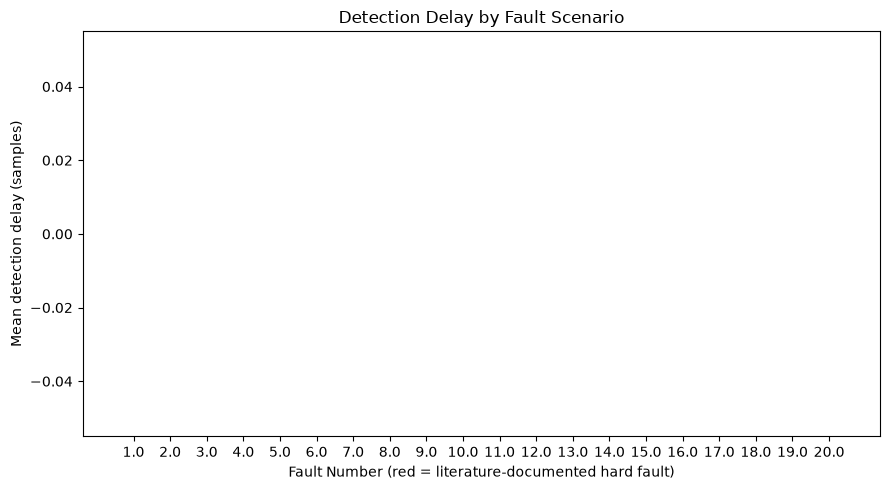

In [8]:
fig, ax = plt.subplots()
mean_delay_by_fault = delays.groupby('faultNumber')['delay_samples'].mean()
colors = ['#b22222' if f in HARD_FAULTS else '#556b2f' for f in mean_delay_by_fault.index]
ax.bar(mean_delay_by_fault.index.astype(str), mean_delay_by_fault.values, color=colors)
ax.set_xlabel('Fault Number (red = literature-documented hard fault)')
ax.set_ylabel('Mean detection delay (samples)')
ax.set_title('Detection Delay by Fault Scenario')
plt.tight_layout()
plt.show()

## 4. Fault diagnosis (multiclass)
Trained and evaluated only on active-fault rows -- diagnosing "which fault" doesn't make sense on rows that are still normal.

In [9]:
diagnosis_results = {}
diagnosis_models = {}
for model_type in ['random_forest', 'hist_gradient_boosting']:
    model = train_diagnosis_model(train_df, model_type=model_type, seed=42)
    diagnosis_models[model_type] = model
    diagnosis_results[model_type] = evaluate_diagnosis_model(model, val_df)

pd.DataFrame(diagnosis_results).T

,accuracy,precision,recall,f1
random_forest,0.784179,0.806655,0.784179,0.794652
hist_gradient_boosting,0.833656,0.854896,0.833656,0.842010


### 4a. Confusion matrix (best model)

In [ ]:
from sklearn.metrics import confusion_matrix 

best_diag_type = pd.DataFrame(diagnosis_results).T['f1'].idxmax()

best_diag_model = diagnosis_models[best_diag_type]
active_val = val_df[val_df['fault_active']]
y_true = active_val['faultNumber']
y_pred = best_diag_model.predict(active_val[feature_columns])

labels = sorted(y_true.unique())
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='YlOrBr')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted fault'); ax.set_ylabel('True fault')
ax.set_title(f'Diagnosis Confusion Matrix ({best_diag_type})')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### 4b. Per-fault diagnosis accuracy
Expect faults 3, 9, 15 to underperform -- that's the known property of the data, not a modeling failure.

In [ ]:
per_fault_accuracy = pd.Series(
    (y_true.values == y_pred), index=y_true.index
).groupby(y_true).mean()

fig, ax = plt.subplots()
colors = ['#b22222' if f in HARD_FAULTS else '#556b2f' for f in per_fault_accuracy.index]
ax.bar(per_fault_accuracy.index.astype(str), per_fault_accuracy.values, color=colors)
ax.set_xlabel('Fault Number (red = literature-documented hard fault)')
ax.set_ylabel('Diagnosis accuracy')
ax.set_title('Per-Fault Diagnosis Accuracy')
plt.tight_layout()
plt.show()

## Takeaways

- Detection vs. diagnosis performance comparison --- TBD
- Random Forest Modeling preferred
- Whether faults 3/9/15 actually underperform as expected in the real data --- TBD
- Detection delay is 0.